MODELO DE INVERSIÓN. 

PARTE I: ESTRUCTURA INICIAL.

Librerías

In [50]:
import pypsa #PyPSA: Python for Power System Analysis
import pandas as pd #Pandas: Biblioteca para manipulación y análisis de datos
import numpy as np #Numpy: Biblioteca para cálculos numéricos
import matplotlib.pyplot as plt #Matplotlib: Biblioteca para creación de gráficos
import matplotlib.dates as mdates #Matplotlib.dates: Módulo para manejar fechas en gráficos

pypsa.options.api.new_components_api = True # Activar la nueva API de componentes de PyPSA

Creación de Snapshot

In [51]:
# (1) Definir el periodo. 
hours=pd.date_range("2025-01-01", periods=24*7, freq="h") # Una semana de 2025 con resolución horaria

# (2) Crear la red vacía con esos snapshots
network=pypsa.Network()
network.set_snapshots(hours)

# (3) Calcular el peso de cada hora para extrapolar a un año completo
hours_per_year=365*24
snapshot_weight=len(hours)
single_weight=hours_per_year/snapshot_weight

#(4) Asignar el peso a cada snapshot
network.snapshot_weightings= pd.Series(single_weight,  index=network.snapshots)

# REVISAR PORQUE CREO QUE AQUÍ YA HAGO LO QUE SE HACE EN EL EXCEL CON LA HOJA SNAPSHOT ENTONCES PODRÍA OMITIRSE SI METEMOS LA HOJA DE SNAPSHOTS DEL EXCEL AQUI.

INFO:pypsa.network.index:Applying weightings to all columns of `snapshot_weightings`


Lectura de Hojas de Datos (excel integrado)

In [52]:
# Lectura de datos desde archivo Excel integrado
data = pd.read_excel(
    r"C:\\Users\\EXT10348\Downloads\\WinPython 3.12.10\\WPy64-31241\\PROYECTOS PYPSA\\Dispatching-Project-in-PypSA\\Modelo_España_Portugal\\Modelo ES_PT_Sin Unir\\modelo_dispatching_españa_portugal_sin_unir.xlsx",
    sheet_name=None,
    engine="openpyxl"
)

In [53]:
# Verificación de correcta lectura de datos
print(data.keys())  # Muestra las hojas disponibles en el archivo Excel

dict_keys(['Guide Sheet', 'carriers', 'buses', 'generators', 'links', 'loads', 'storage_units', 'store', 'snaptshots', 'demands', 'run_of_river_inflow', 'profiles'])


In [54]:

file = "C:\\Users\\EXT10348\\Downloads\\WinPython 3.12.10\\WPy64-31241\\PROYECTOS PYPSA\\Dispatching-Project-in-PypSA\\Modelo_España_Portugal\\Modelo ES_PT_Sin Unir\\modelo_dispatching_españa_portugal_sin_unir.xlsx" # Ruta al archivo Excel
hours_week = 168 # flexible para definir semanas
hours_year = 8760 # flexible para definir años
#---------------------------------------------------------------------------------------------------------
# Perfiles de generación renovable
df_profiles = pd.read_excel(file, sheet_name="profiles") # Leer la hoja 'profiles' del archivo Excel
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) # Asegurar que la columna de fecha es datetime
    # ESPAÑA
ES_solar_profile     = df_profiles["ES_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
ES_wind_profile      = df_profiles["ES_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
    # PORTUGAL
PT_solar_profile     = df_profiles["PT_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
PT_wind_profile     = df_profiles["PT_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
#---------------------------------------------------------------------------------------------------------
# Run of river inflow
df_run_of_river_inflow = pd.read_excel(file, sheet_name="run_of_river_inflow") # Leer la hoja 'profiles' del archivo Excel
df_run_of_river_inflow["date"] = pd.to_datetime(df_run_of_river_inflow["date"]) # Asegurar que la columna de fecha es datetime
    # ESPAÑA
ES_hydraulic_profile = df_run_of_river_inflow["ES_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True) 
    # PORTUGAL
PT_hydraulic_profile = df_run_of_river_inflow["PT_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True)
#---------------------------------------------------------------------------------------------------------
# Demandas
df_demand2040 = pd.read_excel(file, sheet_name="demands") 
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) 
    # ESPAÑA
ES_demand_2040 = df_demand2040["ES_demand_2040"].iloc[:hours_week].reset_index(drop=True)
ES_hydrogen_demand = df_demand2040["ES_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)
    # PORTUGAL
PT_demand_2040 = df_demand2040["PT_demand_2040"].iloc[:hours_week].reset_index(drop=True)
PT_hydrogen_demand = df_demand2040["PT_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)


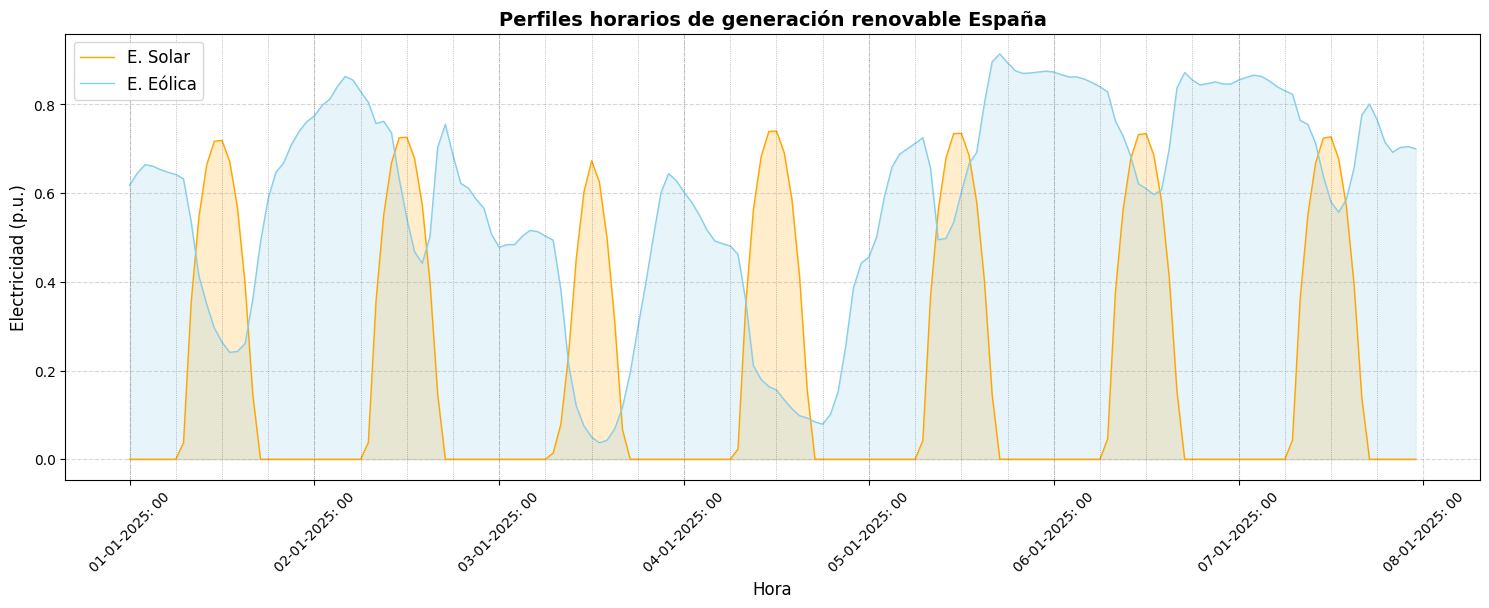

In [55]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_solar_profile, label="E. Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, ES_wind_profile, label="E. Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.title("Perfiles horarios de generación renovable España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, ES_solar_profile, color="orange", alpha=0.2)
plt.fill_between(hours, ES_wind_profile, color="skyblue", alpha=0.2)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()



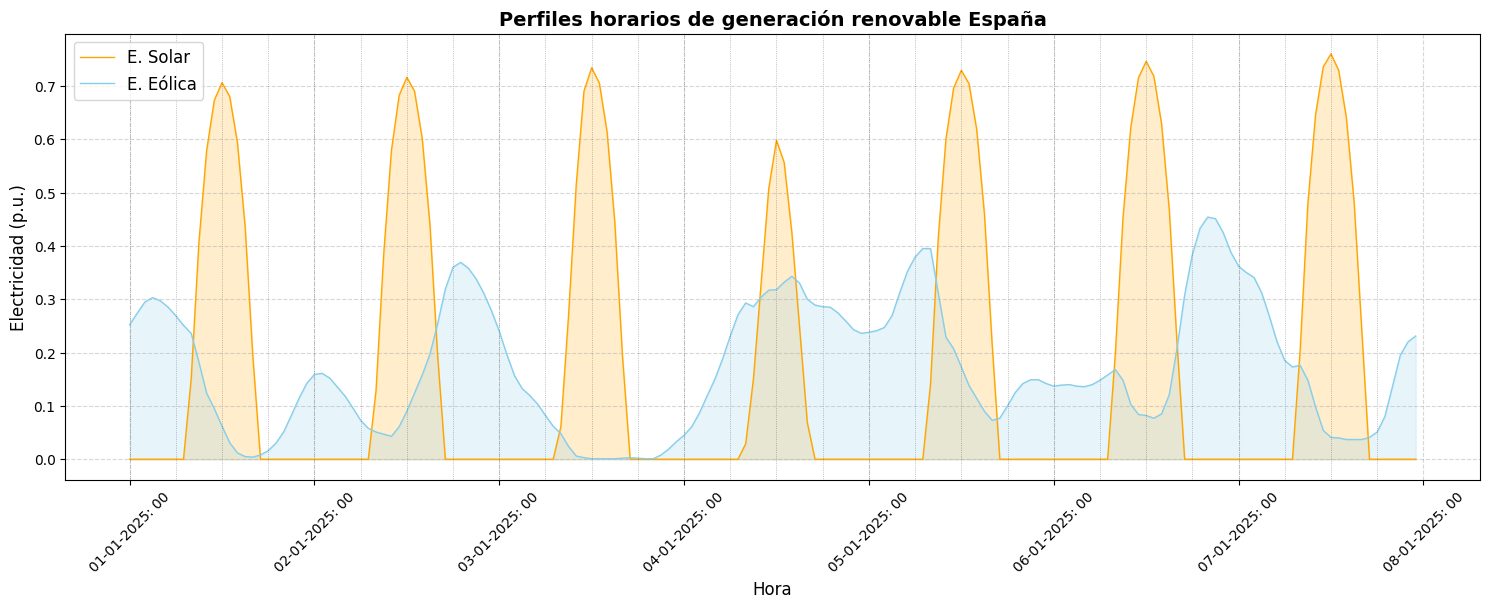

In [56]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_solar_profile, label="E. Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, PT_wind_profile, label="E. Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.title("Perfiles horarios de generación renovable España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, PT_solar_profile, color="orange", alpha=0.2)
plt.fill_between(hours, PT_wind_profile, color="skyblue", alpha=0.2)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

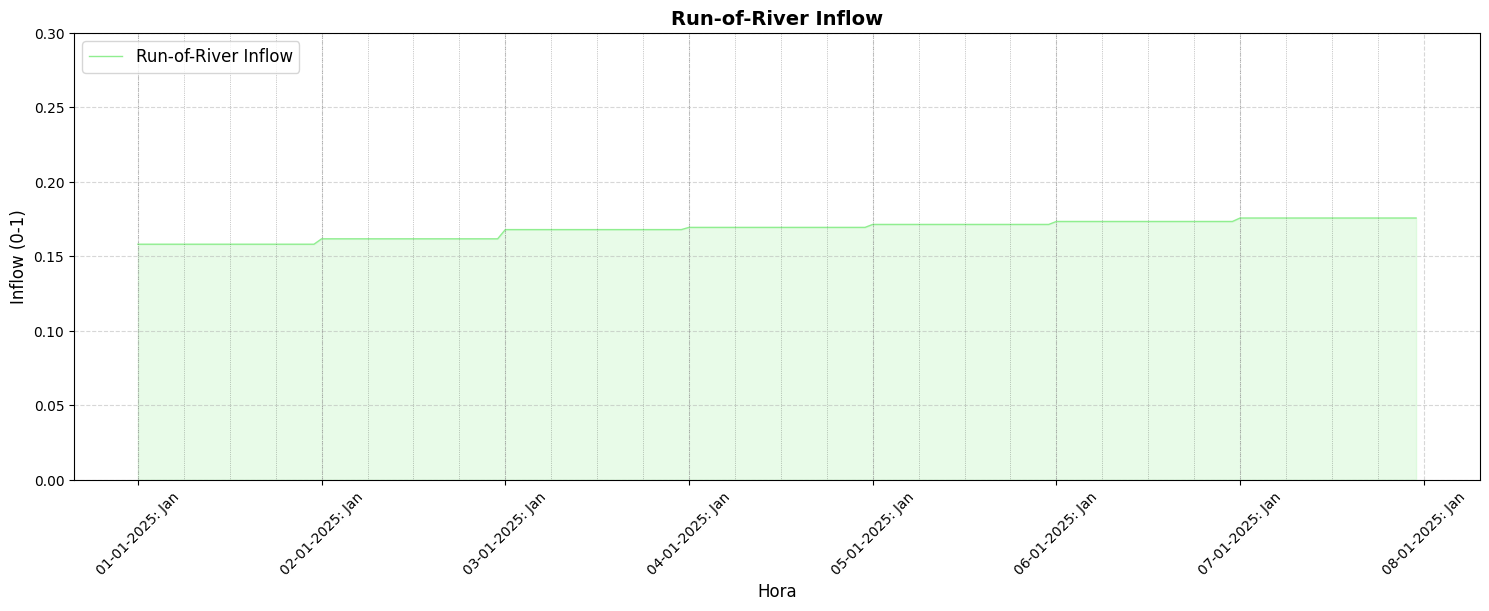

In [57]:

#Gráfica Inflow Run-of-River
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora

plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_hydraulic_profile, label="Run-of-River Inflow", color="lightgreen", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_hydraulic_profile, color="lightgreen", alpha=0.2)
plt.title("Run-of-River Inflow", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Inflow (0-1)", fontsize=12)
plt.ylim(0, 0.3)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

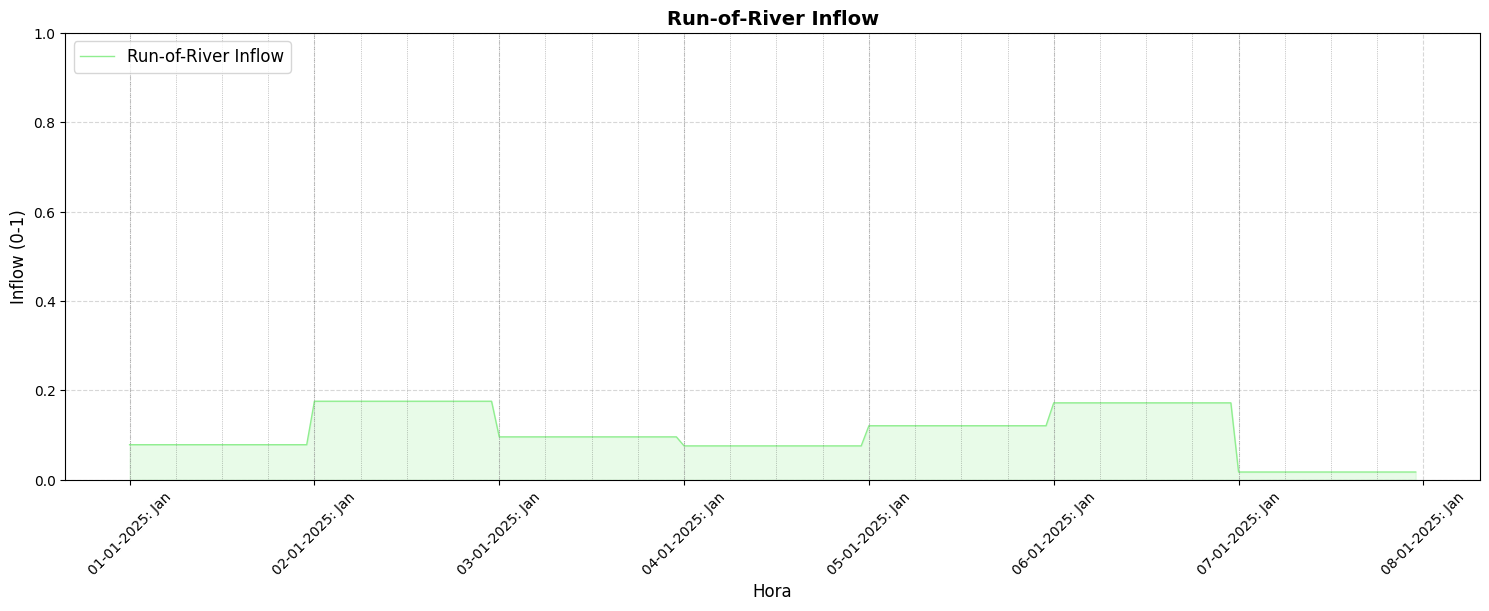

In [58]:
#Gráfica Inflow Run-of-River
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora

plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_hydraulic_profile, label="Run-of-River Inflow", color="lightgreen", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_hydraulic_profile, color="lightgreen", alpha=0.2)
plt.title("Run-of-River Inflow", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Inflow (0-1)", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\1936128452.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



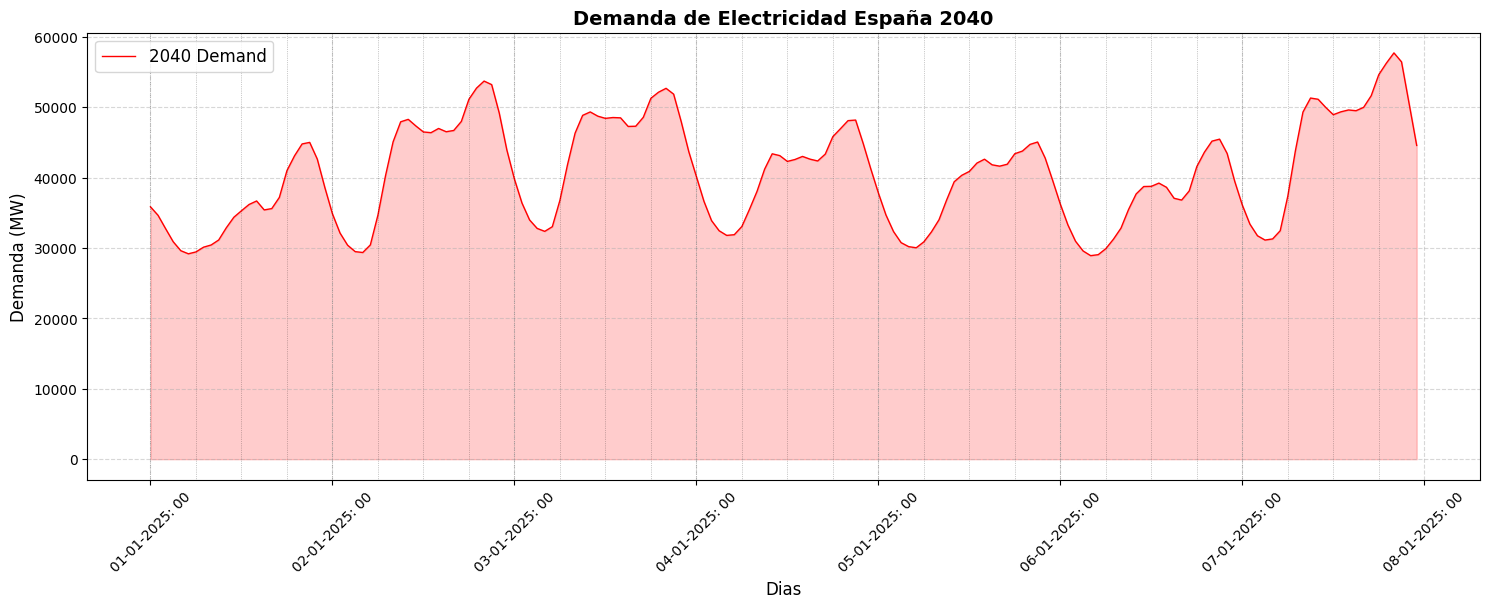

In [59]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_demand_2040, label="2040 Demand", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad España 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

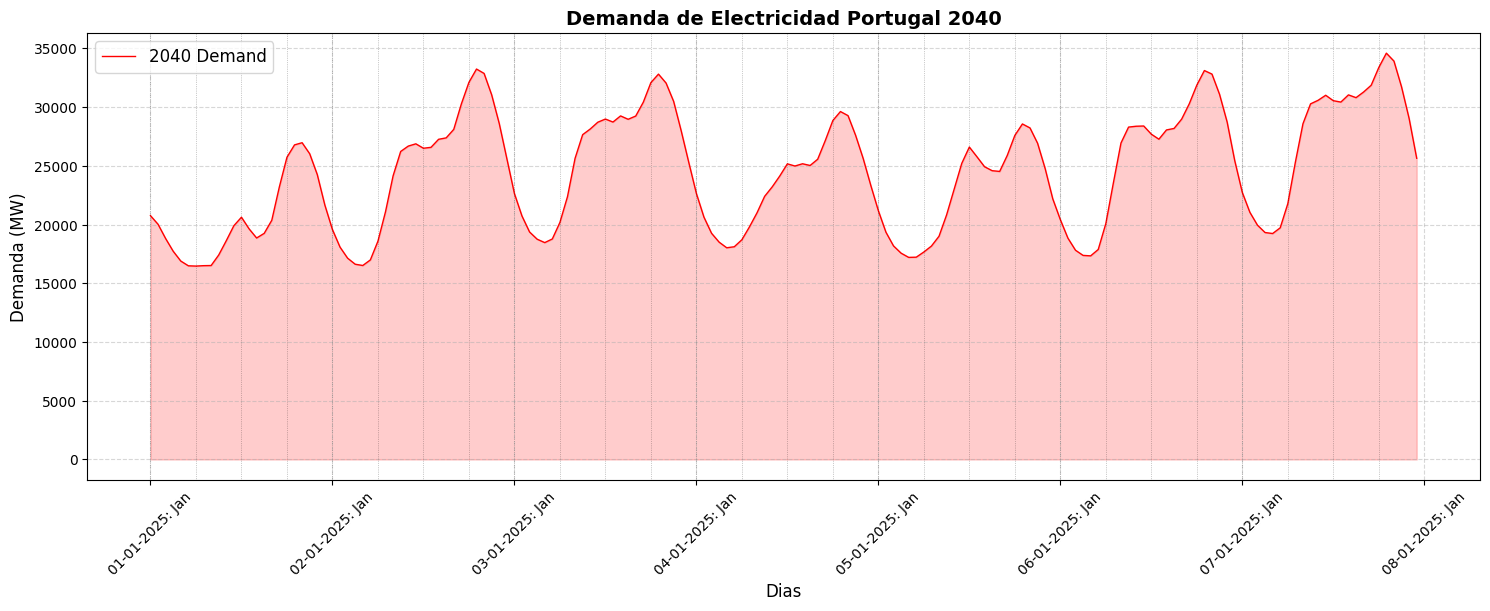

In [60]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_demand_2040, label="2040 Demand", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad Portugal 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

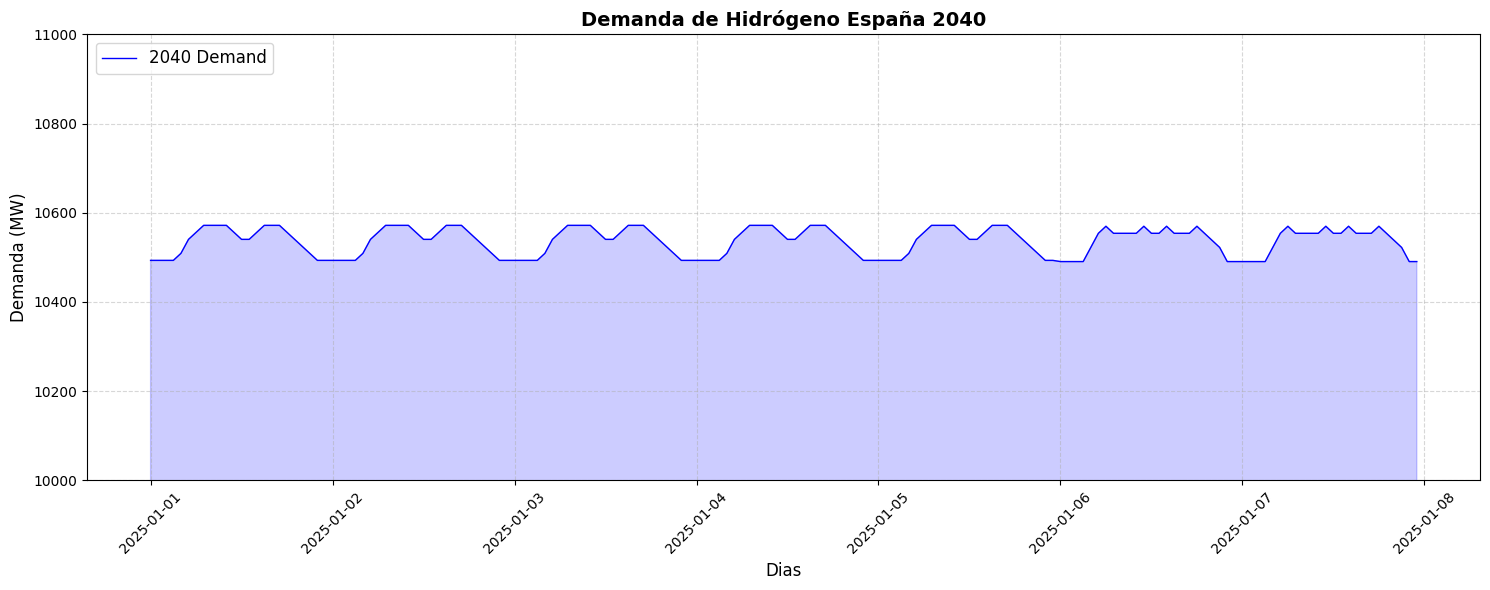

In [61]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_hydrogen_demand, label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno España 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(10000, 11000)


plt.xticks(rotation=45)
plt.show()

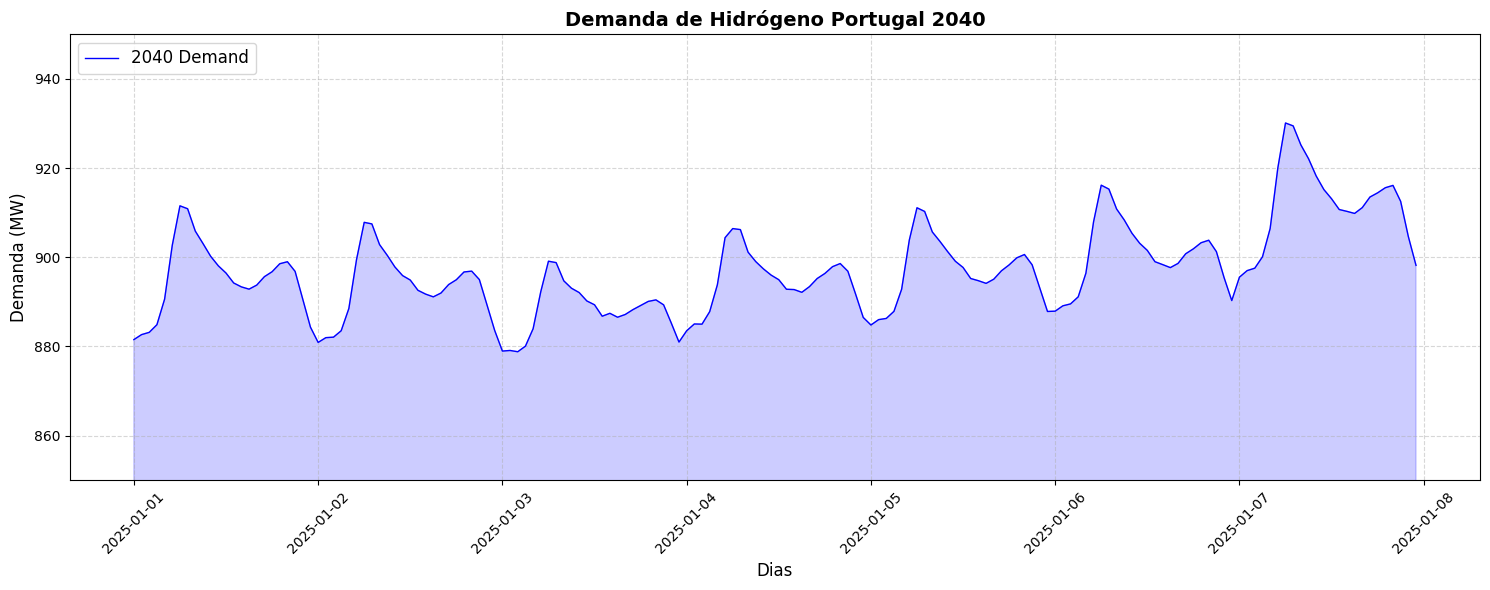

In [62]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_hydrogen_demand, label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno Portugal 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(850, 950)

plt.xticks(rotation=45)
plt.show()

PARTE II: CREACIÓN DEL ENTORNO: Llamada a Componentes

In [63]:
# CARRIERS
df_carriers = data["carriers"]

for _, carrier in df_carriers.iterrows():
    network.add(
        "Carrier",
        carrier["name"].strip(),
        overwrite=carrier["overwrite"]
    )

# Verificación con API moderna
print("\n=== Carriers añadidos ===")
print(network.carriers.static)




=== Carriers añadidos ===
             co2_emissions color nice_name  max_growth  max_relative_growth
name                                                                       
AC                     0.0                         inf                  0.0
water                  0.0                         inf                  0.0
wind                   0.0                         inf                  0.0
gas                    0.0                         inf                  0.0
solar                  0.0                         inf                  0.0
grid_import            0.0                         inf                  0.0
biomass                0.0                         inf                  0.0
hydrogen               0.0                         inf                  0.0


In [64]:
# BUSES
df_buses = data["buses"]

for _, bus in df_buses.iterrows():
    network.add(
        "Bus",
        bus["name"],
        carrier=bus["carrier"],
        overwrite=bool(bus["overwrite"]),
        x=float(bus["x"]) if "x" in df_buses.columns and pd.notna(bus["x"]) else np.nan,
        y=float(bus["y"]) if "y" in df_buses.columns and pd.notna(bus["y"]) else np.nan,
    )

# Verificación con API moderna
print("\n=== Buses añadidos ===")
print(network.buses.static)  



=== Buses añadidos ===
                           v_nom type       x        y   carrier unit  \
name                                                                    
ES_electricity_market_bus    1.0      -3.7038  40.4168        AC        
ES_water_bus                 1.0      -3.7038  40.4168    water         
ES_gas_bus                   1.0      -3.7038  40.4168       gas        
ES_hydrogen_bus              1.0      -3.7038  40.4168  hydrogen        
PT_electricity_market_bus    1.0      -9.1393  38.7223        AC        
PT_water_bus                 1.0      -9.1393  38.7223    water         
PT_gas_bus                   1.0      -9.1393  38.7223       gas        
PT_hydrogen_bus              1.0      -9.1393  38.7223  hydrogen        

                          location  v_mag_pu_set  v_mag_pu_min  v_mag_pu_max  \
name                                                                           
ES_electricity_market_bus                    1.0           0.0           inf   
ES_wa

In [65]:
# GENERADORES

df_generators = data["generators"]

for _, gen in df_generators.iterrows(): 
    gen_name = gen["name"].strip() 
    carrier_key = gen["carrier"].strip().lower() 
    
    # Detectar si es ES o PT según el bus
    country = gen["bus"][:2]   # ES / PT

    # Crear el generador estático
    network.add( 
        "Generator",
        gen_name,
        bus=gen["bus"],
        p_nom=gen["p_nom"],
        # p_nom_extendable=gen["p_nom_extendable"],
        # p_nom_max=gen["p_nom_max"],
        marginal_cost=gen["marginal_cost"],
        carrier=gen["carrier"],
        overwrite=gen["overwrite"]
    )

    # Seleccionar perfil correcto según país + carrier
    if carrier_key == "solar":
        profile = ES_solar_profile if country == "ES" else PT_solar_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "wind":
        profile = ES_wind_profile if country == "ES" else PT_wind_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "water":
        profile = ES_hydraulic_profile if country == "ES" else PT_hydraulic_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    else:
        continue  # carrier no renovable → no tiene perfil dinámico



In [66]:
print(network.generators)
print(network.generators.dynamic["p_max_pu"].columns)

'Generator' Components
Index(['ES_solar', 'ES_wind', 'ES_water', 'PT_solar', 'PT_wind', 'PT_water'], dtype='object', name='name')


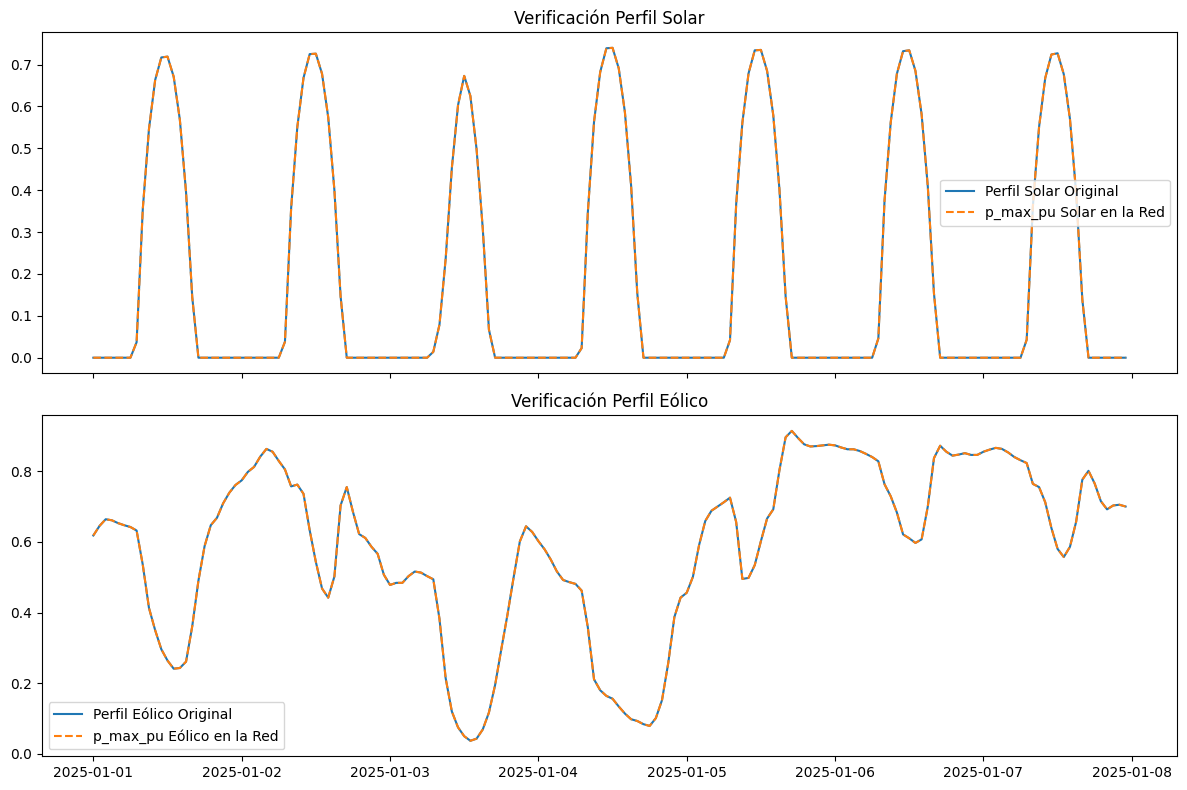

In [67]:
# Verificación de perfiles asignados correctamente: ES
ES_solar_profile.index = network.snapshots[:len(ES_solar_profile)]
ES_wind_profile.index = network.snapshots[:len(ES_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["ES_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["ES_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], ES_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], ES_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()



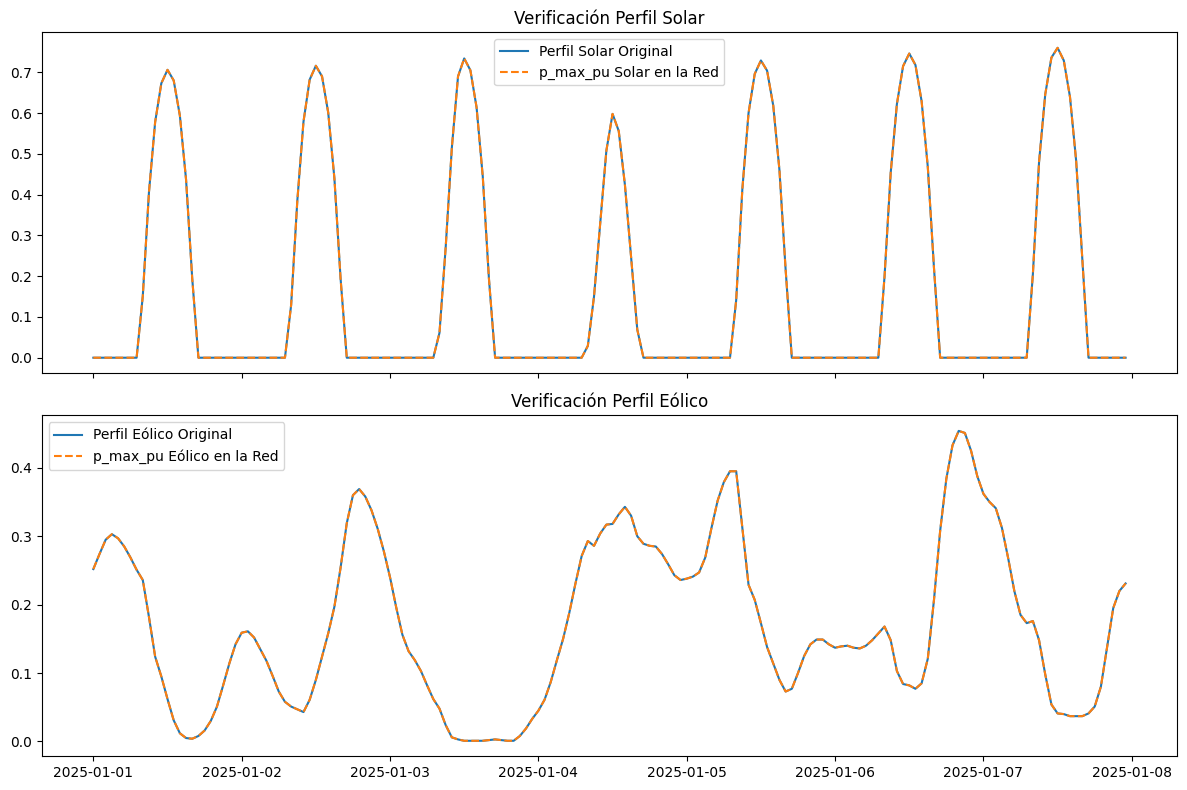

In [68]:
# Verificación de perfiles asignados correctamente: PT
PT_solar_profile.index = network.snapshots[:len(PT_solar_profile)]
PT_wind_profile.index = network.snapshots[:len(PT_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["PT_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["PT_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], PT_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], PT_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()


In [69]:
# LOADS

# CREAR SERIES DE DEMANDA
    #ESPAÑA
ES_demand_hydrogen_series = pd.Series(df_demand2040['ES_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
ES_demand_series = pd.Series(df_demand2040['ES_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)
    #PORTUGAL
PT_demand_hydrogen_series = pd.Series(df_demand2040['PT_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
PT_demand_series = pd.Series(df_demand2040['PT_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)

# Añadir variables estáticas
df_loads = data["loads"]
for _, load in df_loads.iterrows():
    network.add(
        "Load",
        load["name"].strip(),
        bus=load["bus"].strip(),
        carrier=load["carrier"].strip(),
        overwrite=load["overwrite"]
    )

# Asignar variables dinámicas
    #ESPAÑA
network.loads.dynamic["p_set"]["ES_hydrogen_demand"] = ES_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["ES_demand_2040"] = ES_demand_series.values
    #PORTUGAL
network.loads.dynamic["p_set"]["PT_hydrogen_demand"] = PT_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["PT_demand_2040"] = PT_demand_series.values

# Verificación con API moderna
print("\n=== Loads estáticos ===")
print(network.loads.static)

print("\n=== Primeras filas de p_set dinámico ===")
print(network.loads.dynamic["p_set"].head())



=== Loads estáticos ===
                                          bus   carrier type  p_set  q_set  \
name                                                                         
ES_demand_2040      ES_electricity_market_bus        AC         0.0    0.0   
ES_hydrogen_demand            ES_hydrogen_bus  hydrogen         0.0    0.0   
PT_demand_2040      PT_electricity_market_bus        AC         0.0    0.0   
PT_hydrogen_demand            PT_hydrogen_bus  hydrogen         0.0    0.0   

                    sign  active  
name                              
ES_demand_2040      -1.0    True  
ES_hydrogen_demand  -1.0    True  
PT_demand_2040      -1.0    True  
PT_hydrogen_demand  -1.0    True  

=== Primeras filas de p_set dinámico ===
name                 ES_hydrogen_demand  ES_demand_2040  PT_hydrogen_demand  \
snapshot                                                                      
2025-01-01 00:00:00         10493.06584    35845.954713          881.545028   
2025-01-01 01:00:

In [70]:
df_links = data["links"]

for _, lk in df_links.iterrows():

    name = lk["name"].strip().lower()
    link_name = lk["name"].strip()

    # Detectar país desde bus0
    country = lk["bus0"][:2]   # ES / PT

    # Añadir link estático
    network.add(
        "Link",
        link_name,
        bus0=lk["bus0"].strip(),
        bus1=lk["bus1"].strip(),
        p_nom=lk["p_nom"],
        efficiency=lk["efficiency"],
        marginal_cost=lk["marginal_cost"],
        carrier=lk["carrier"],
        capital_cost=lk["capital_cost"],
        overwrite=lk["overwrite"]
    )



In [71]:
# Verificación
     
print("\n=== Resumen de todos los Links en la red ===")
print(network.links.static[['bus0','bus1','p_nom','efficiency','marginal_cost','carrier']])
for link_name in ["CCGT", "turbina", "pump", "electrolyzer"]:
        if link_name in network.links.static.index:
            row = network.links.static.loc[link_name]
            print(f"\n--- Detalle de {link_name} ---")
            print(f"Origen (bus0):        {row['bus0']}")
            print(f"Destino (bus1):       {row['bus1']}")
            print(f"Capacidad (p_nom):    {row['p_nom']} MW")
            print(f"Eficiencia:           {row['efficiency']*100:.1f}%")
            print(f"Coste marginal:       {row['marginal_cost']} €/MWh")
            print(f"Carrier:              {row['carrier']}")
            # Ramp limits solo para CCGT
            #if link_name == "CCGT":
            #    print(f"Ramp up limit:        {row['ramp_limit_up']} MW/h")
            #    print(f"Ramp down limit:      {row['ramp_limit_down']} MW/h")
        else:
            print(f"\n⚠️ El link '{link_name}' no se encontró en la red.")


=== Resumen de todos los Links en la red ===
                                      bus0                       bus1  \
name                                                                    
ES_CCGT                         ES_gas_bus  ES_electricity_market_bus   
ES_turbina                    ES_water_bus  ES_electricity_market_bus   
ES_pump          ES_electricity_market_bus               ES_water_bus   
ES_electrolyzer  ES_electricity_market_bus            ES_hydrogen_bus   
PT_CCGT                         PT_gas_bus  PT_electricity_market_bus   
PT_turbina                    PT_water_bus  PT_electricity_market_bus   
PT_pump          PT_electricity_market_bus               PT_water_bus   
PT_electrolyzer  PT_electricity_market_bus            PT_hydrogen_bus   

                        p_nom  efficiency  marginal_cost   carrier  
name                                                                
ES_CCGT          24559.640000        0.58           96.0       gas  
ES_turbina      

In [72]:
print("\nLINKS ESTÁTICOS:")
print(network.links.static.index)

print("\nCOLUMNAS EN p_max_pu:")
print(network.links.dynamic["p_max_pu"].columns)

print("\nCOLUMNAS EN p0:")
print(network.links_t.p0.columns)


LINKS ESTÁTICOS:
Index(['ES_CCGT', 'ES_turbina', 'ES_pump', 'ES_electrolyzer', 'PT_CCGT',
       'PT_turbina', 'PT_pump', 'PT_electrolyzer'],
      dtype='object', name='name')

COLUMNAS EN p_max_pu:
Index([], dtype='object', name='name')

COLUMNAS EN p0:
Index([], dtype='object', name='name')


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\4154381567.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



In [73]:

df_storage = data["storage_units"]

for _, st in df_storage.iterrows():
    name = st["name"].strip()

    # Añadir atributos estáticos
    network.add(
        "StorageUnit",
        name,
        bus=st["bus"].strip(),
        p_nom=st["p_nom"],
        max_hours=st["max_hours"],
        efficiency_store=st["efficiency_store"],
        efficiency_dispatch=st["efficiency_dispatch"],
        marginal_cost=st["marginal_cost"],
        carrier=st["carrier"],
        overwrite=st["overwrite"],
        capital_cost=st.get("capital_cost", 0),  # si existe
        #state_of_charge_initial=0.5 * st["p_nom"] * st["max_hours"],  
        cyclic_state_of_charge=False
    )


    print(f"✅ StorageUnit '{name}' añadida en bus {st['bus']}: {st['p_nom']} MW · {st['max_hours']} h")

# Verificación
print("\n=== Storage Units estáticos ===")
print(network.storage_units.static.head())

print("\n=== Storage Units dinámicos ===")
print(network.storage_units.dynamic.keys())


✅ StorageUnit 'ES_electricity_market_battery' añadida en bus ES_electricity_market_bus: 26698.52 MW · 4 h
✅ StorageUnit 'ES_hydrogen_storage' añadida en bus ES_hydrogen_bus: 10000.0 MW · 1000 h
✅ StorageUnit 'PT_electricity_market_battery' añadida en bus PT_electricity_market_bus: 3000.0 MW · 4 h
✅ StorageUnit 'PT_hydrogen_storage' añadida en bus PT_hydrogen_bus: 10000.0 MW · 1000 h

=== Storage Units estáticos ===
                                                     bus control type  \
name                                                                    
ES_electricity_market_battery  ES_electricity_market_bus      PQ        
ES_hydrogen_storage                      ES_hydrogen_bus      PQ        
PT_electricity_market_battery  PT_electricity_market_bus      PQ        
PT_hydrogen_storage                      PT_hydrogen_bus      PQ        

                                  p_nom  p_nom_mod  p_nom_extendable  \
name                                                                  

In [74]:
df_store = data["store"].copy()
 
# normaliza la columna a boolean REAL
df_store["cyclic_state_of_charge"] = (
    df_store["cyclic_state_of_charge"]
    .astype(str).str.strip().str.lower()
    .map({"true": True, "false": False, "1": True, "0": False, "nan": False})
)
 
# si algo no mapea, lo dejamos en False (o lanza error si prefieres)
df_store["cyclic_state_of_charge"] = df_store["cyclic_state_of_charge"].fillna(False)

In [75]:

df_store = data["store"]

for _, store in df_store.iterrows():
    network.add(
        "Store",
        store["name"].strip(),
        bus=store["bus"].strip(),
        e_nom=store["e_nom"],
        e_initial=store["e_initial"], 
        e_min_pu=store["e_min_pu"],
        e_max_pu=store["e_max_pu"],
        e_cyclic=store["cyclic_state_of_charge"],
        capital_cost=store["capital_cost"],
        marginal_cost=store["marginal_cost"],
        carrier=store["carrier"],
        overwrite=store["overwrite"]
    )

    print(f"✅ Store '{store['name']}' añadida en bus {store['bus']}: "
          f"{store['e_nom']} MWh · inicial {store['e_initial']} MWh · "
          f"min {store['e_min_pu']} pu · max {store['e_max_pu']} pu · "
          f"coste marginal {store['marginal_cost']}")

# Verificación con API moderna
print("\n=== Stores estáticos ===")
print(network.stores.static.head())


✅ Store 'ES_embalse' añadida en bus ES_water_bus: 1387684000 MWh · inicial 1248915600 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1


✅ Store 'PT_embalse' añadida en bus PT_water_bus: 3307600 MWh · inicial 2976840 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1

=== Stores estáticos ===
                     bus type carrier         e_nom  e_nom_mod  \
name                                                             
ES_embalse  ES_water_bus        water  1.387684e+09        0.0   
PT_embalse  PT_water_bus        water  3.307600e+06        0.0   

            e_nom_extendable  e_nom_min  e_nom_max  e_nom_set  e_min_pu  ...  \
name                                                                     ...   
ES_embalse             False        0.0        inf        NaN       0.2  ...   
PT_embalse             False        0.0        inf        NaN       0.2  ...   

            sign  marginal_cost  marginal_cost_quadratic  \
name                                                       
ES_embalse   1.0            1.0                      0.0   
PT_embalse   1.0            1.0                      0.0   

            margi

RESTRICCIONES

In [76]:
# EMISIONES DE CO2.
# --------------------------- Precio CO2 y factor de emisión --------------------------------
#co2_price = 100  # €/tCO2
#emission_factor = 0.202  # tCO2/MWh para gas
#--------------------------- Coste adicional por CO2 ----------------------------------------
#co2_cost = co2_price * emission_factor  # 20.2 €/MWh
#--------------------------- Sumarlo al coste marginal del link CCGT ------------------------
#network.links.at["CCGT", "marginal_cost"] += co2_cost

# network.optimize.add_load_shedding(marginal_cost=1e6)
# status, cond = network.optimize(solver_name="highs")
# print(status, cond)

PARTE III: OPTIMIZACIÓN

In [77]:
network.optimize(solver_name="highs")

Index(['ES_water_bus', 'PT_water_bus'], dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.17s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 5712 primals, 13104 duals
Objective: 6.89e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

PARTE IV: OBTENCIÓN DE RESULTADOS.

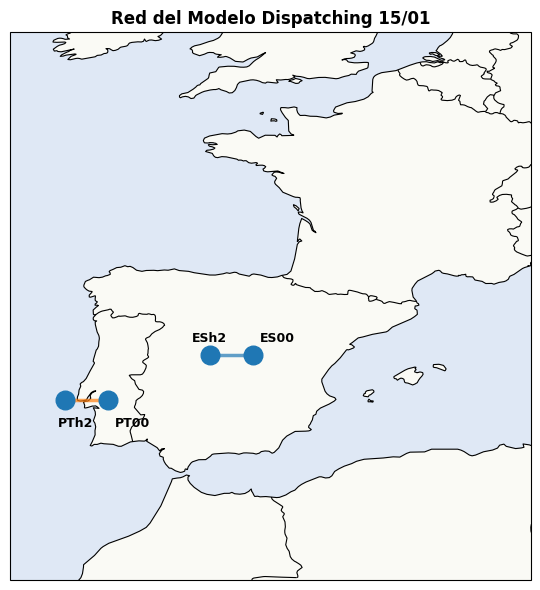

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -------------------------------------------------
# 1) BUSES DEL BENCHMARKING 2busSRES
# -------------------------------------------------
wanted_buses = [
    "ES_electricity_market_bus",
    "ES_hydrogen_bus",
    "PT_electricity_market_bus",
    "PT_hydrogen_bus",

]

# API robusta para buses
if hasattr(network.buses, "static"):
    buses_df = network.buses.static.copy()
elif hasattr(network.buses, "df"):
    buses_df = network.buses.df.copy()
else:
    buses_df = network.buses.copy()

# quedarnos solo con los que realmente existen en la red
existing_buses = [b for b in wanted_buses if b in buses_df.index]

missing_buses = [b for b in wanted_buses if b not in buses_df.index]
if missing_buses:
    print("WARNING - buses no encontrados en la red:", missing_buses)

bdf = buses_df.loc[existing_buses, ["x", "y", "carrier"]].copy()

# -------------------------------------------------
# 2) JITTER para separar buses con misma coordenada
# -------------------------------------------------
jitter = 0.8

grouped = bdf.groupby(["x", "y"])

for (x, y), idx in grouped.groups.items():
    idx = list(idx)
    if len(idx) > 1:
        angles = np.linspace(0, 2 * np.pi, len(idx), endpoint=False)
        for i, bus in enumerate(idx):
            bdf.loc[bus, "x"] = x + jitter * np.cos(angles[i])
            bdf.loc[bus, "y"] = y + jitter * np.sin(angles[i])

# -------------------------------------------------
# 3) INTERCONEXIONES ENTRE ELLOS
# -------------------------------------------------
edges = []

def add_edges(df, bus0="bus0", bus1="bus1"):
    if df is None or len(df) == 0:
        return
    for _, r in df.iterrows():
        if (r[bus0] in bdf.index) and (r[bus1] in bdf.index):
            edges.append((r[bus0], r[bus1]))

# Links
if hasattr(network, "links"):
    if hasattr(network.links, "static"):
        add_edges(network.links.static)
    elif hasattr(network.links, "df"):
        add_edges(network.links.df)
    else:
        add_edges(network.links)

# Lines
if hasattr(network, "lines"):
    if hasattr(network.lines, "static"):
        add_edges(network.lines.static)
    elif hasattr(network.lines, "df"):
        add_edges(network.lines.df)
    else:
        add_edges(network.lines)

# Transformers
if hasattr(network, "transformers"):
    if hasattr(network.transformers, "static"):
        add_edges(network.transformers.static)
    elif hasattr(network.transformers, "df"):
        add_edges(network.transformers.df)
    else:
        add_edges(network.transformers)

# eliminar duplicados visuales
edges = list(dict.fromkeys(edges))

# -------------------------------------------------
# 4) MAPA BASE
# -------------------------------------------------
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, alpha=0.25)
ax.add_feature(cfeature.OCEAN, alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

ax.set_extent([-12, 7.5, 32.0, 52.5], crs=ccrs.PlateCarree())

# -------------------------------------------------
# 5) DIBUJAR INTERCONEXIONES
# -------------------------------------------------
for b0, b1 in edges:
    x0, y0 = bdf.loc[b0, ["x", "y"]]
    x1, y1 = bdf.loc[b1, ["x", "y"]]

    ax.plot(
        [x0, x1],
        [y0, y1],
        linewidth=2.5,
        alpha=0.7,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

# -------------------------------------------------
# 6) DIBUJAR BUSES
# -------------------------------------------------
ax.scatter(
    bdf["x"],
    bdf["y"],
    s=180,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

label_offset = {
    "ES_electricity_market_bus": (0.25, 0.5),
    "ES_hydrogen_bus": (-0.7, 0.5),
    "PT_electricity_market_bus": (0.25, -1),
    "PT_hydrogen_bus": (-0.25, -1),

}

label_map = {
    "ES_electricity_market_bus": "ES00",
    "ES_hydrogen_bus": "ESh2",
    "PT_electricity_market_bus": "PT00",
    "PT_hydrogen_bus": "PTh2",

}

for name, r in bdf.iterrows():
    label = label_map.get(name, name)
    dx, dy = label_offset.get(name, (0.2, 0.2))

    ax.text(
        r["x"] + dx,
        r["y"] + dy,
        label,
        transform=ccrs.PlateCarree(),
        fontsize=9,
        fontweight="bold",
        zorder=6,
    )

ax.set_title(
    "Red del Modelo Dispatching 15/01",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x1ec535cb6b0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x1ec53560170>},
 'flows': {}}

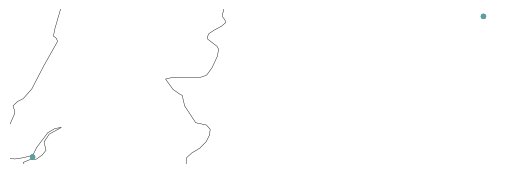

In [79]:
network.plot(bus_sizes=0.001, link_widths=1)

In [80]:
network.generators.static.query("bus.str.startswith('PT')")[["p_nom","carrier"]]

,p_nom,carrier
name,,
PT_solar,7.432600e+04,solar
PT_wind,4.442320e+04,wind
PT_biomass,1.607000e+03,biomass
PT_gas,1.000000e+14,gas
PT_water,5.083000e+02,water


In [81]:
PT_demand_2040.max()

34597.00195694716

In [82]:
network.links.static.query("bus1.str.startswith('PT')")

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
PT_CCGT,PT_gas_bus,PT_electricity_market_bus,,gas,1.00,True,0,inf,40000.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,40000.0
PT_turbina,PT_water_bus,PT_electricity_market_bus,,water,1.00,True,0,inf,7604.9,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,7604.9
PT_pump,PT_electricity_market_bus,PT_water_bus,,AC,1.00,True,0,inf,3837.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,3837.0
PT_electrolyzer,PT_electricity_market_bus,PT_hydrogen_bus,,hydrogen,0.68,True,0,inf,13478.0,0.0,...,0.0,0,0,1,0,NaN,NaN,1.0,1.0,13478.0


In [83]:
# RESULTADOS NUMÉRICOS QUE CUBREN LA DEMANDA
print(" Generator p:", network.generators_t.p.iloc[0])
print("Link p0:",     network.links_t.p0.iloc[0])
print("Link p1:",     network.links_t.p1.iloc[0])
print(" Load p:",      network.loads_t.p_set.iloc[0])

 Generator p: name
ES_solar         -0.000000
ES_wind       50836.048770
ES_biomass       -0.000000
ES_gas           -0.000000
ES_water         -0.000000
PT_solar         -0.000000
PT_wind       11194.646400
PT_biomass     1607.000000
PT_gas         8072.238433
PT_water         39.876589
Name: 2025-01-01 00:00:00, dtype: float64
Link p0: name
ES_CCGT               -0.000000
ES_turbina            -0.000000
ES_pump               -0.000000
ES_electrolyzer    14990.094057
PT_CCGT             8072.238433
PT_turbina          1143.670986
PT_pump               -0.000000
PT_electrolyzer     1296.389747
Name: 2025-01-01 00:00:00, dtype: float64
Link p1: name
ES_CCGT                0.000000
ES_turbina             0.000000
ES_pump                0.000000
ES_electrolyzer   -10493.065840
PT_CCGT            -8072.238433
PT_turbina         -1143.670986
PT_pump                0.000000
PT_electrolyzer     -881.545028
Name: 2025-01-01 00:00:00, dtype: float64
 Load p: name
ES_hydrogen_demand    10493.065

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\543772787.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\543772787.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\543772787.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\543772787.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` a

In [84]:
# Guardar resultados en un archivo Excel
network.export_to_excel(
    r"C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\Modelo_España_Portugal\hojas_de_datosresultados.xlsx",
    engine="openpyxl"
)


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\Modelo_España_Portugal\hojas_de_datosresultados.xlsx contains: sub_networks, stores, buses, generators, loads, carriers, links, storage_units


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\2743041598.py:10: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\2743041598.py:11: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



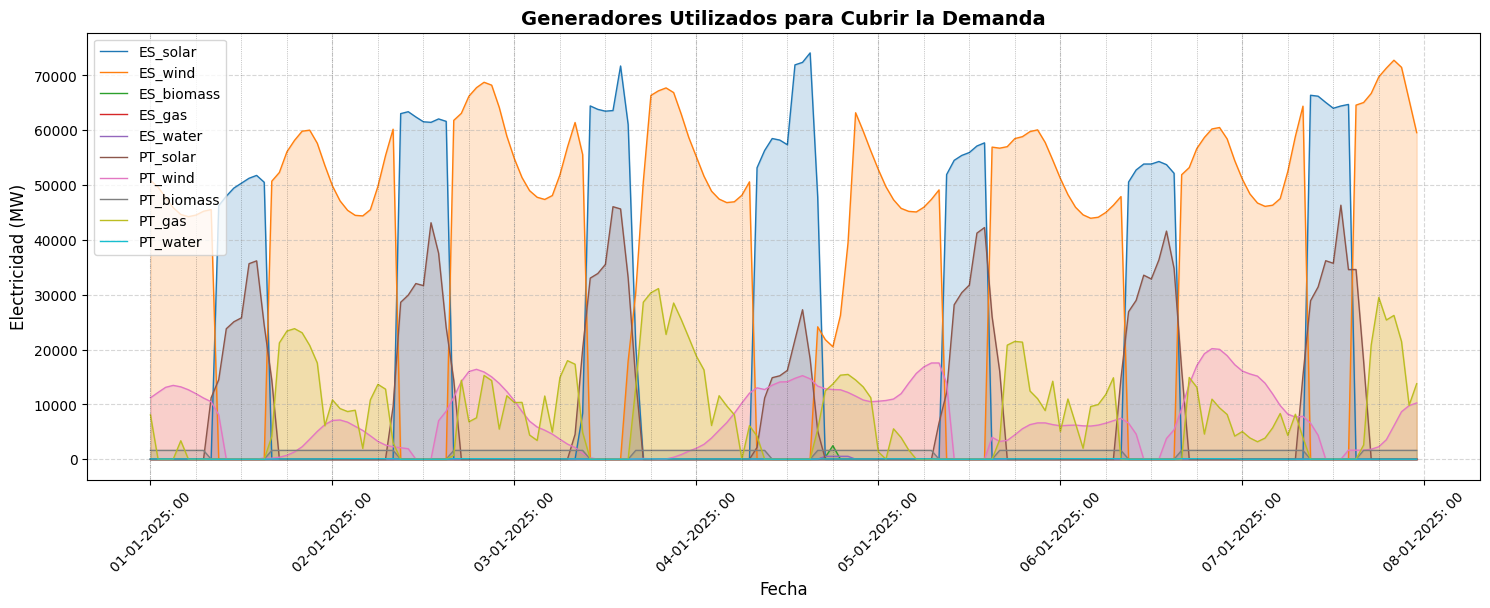

In [85]:
# Gráfica de Generadores Utilizados para Cubrir la Demanda España
# ----------------------------------------------------------------------------------------------------------------------------------------
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") 

plt.figure(figsize=(15, 6))
plt.style.use('default')
# -------------------- Graficar cada generador manualmente ------------------------------------------------------------------------------
for gen in network.generators.dynamic["p"]:
    
    y= network.generators_t.p[gen]
    plt.plot(hours, network.generators_t.p[gen], label=gen, linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)
# -------------------- Personalización --------------------------------------------------------------------------------------------------
plt.title("Generadores Utilizados para Cubrir la Demanda", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# --------------------- Líneas verticales -----------------------------------------------------------------------------------------------
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# --------------------- Formato del eje X ------------------------------------------------------------------------------------------------
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# ----------------------------------------------------------------------------------------------------------------------------------------
plt.show()
# ----------------------------------------------------------------------------------------------------------------------------------------

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\3632697900.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\3632697900.py:9: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



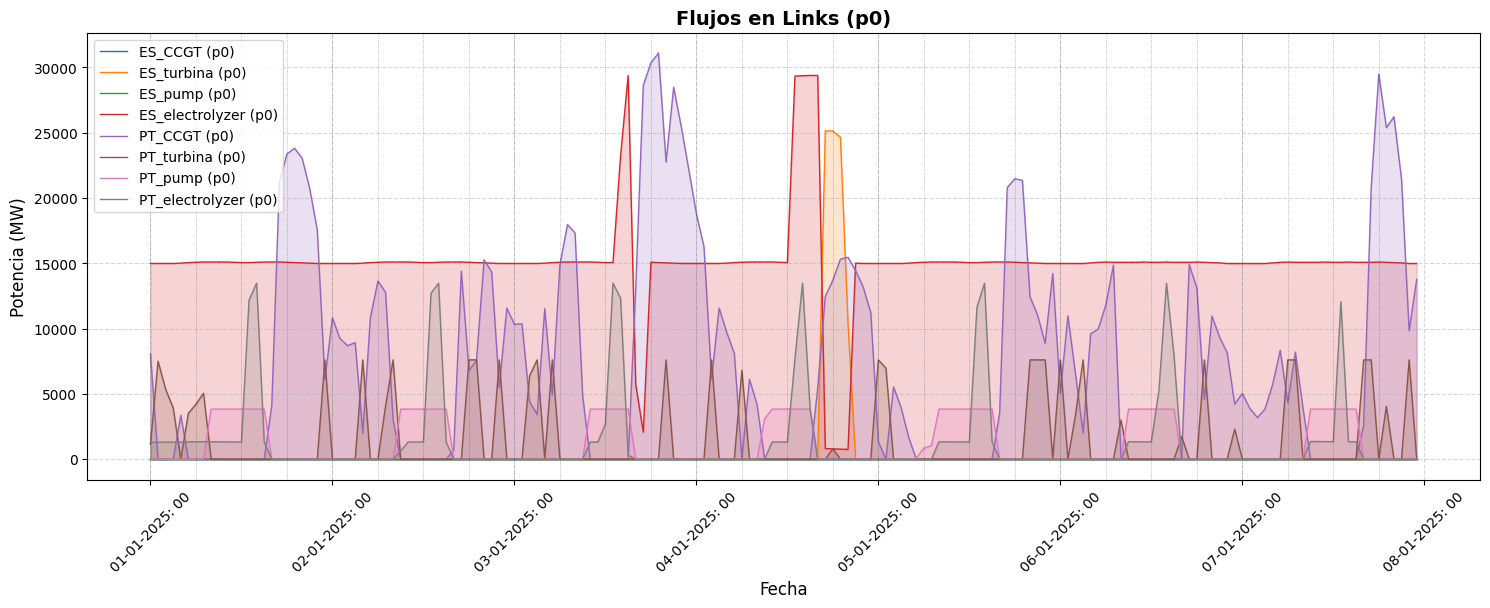

In [86]:
# Flujos en Links
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")

plt.figure(figsize=(15, 6))
plt.style.use('default')

# Graficar cada link manualmente (p0)
for link in network.links_t.p0.columns:
    y = network.links_t.p0[link]
    plt.plot(hours, y, label=f"{link} (p0)", linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)

# Personalización
plt.title("Flujos en Links (p0)", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Líneas verticales
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.show()


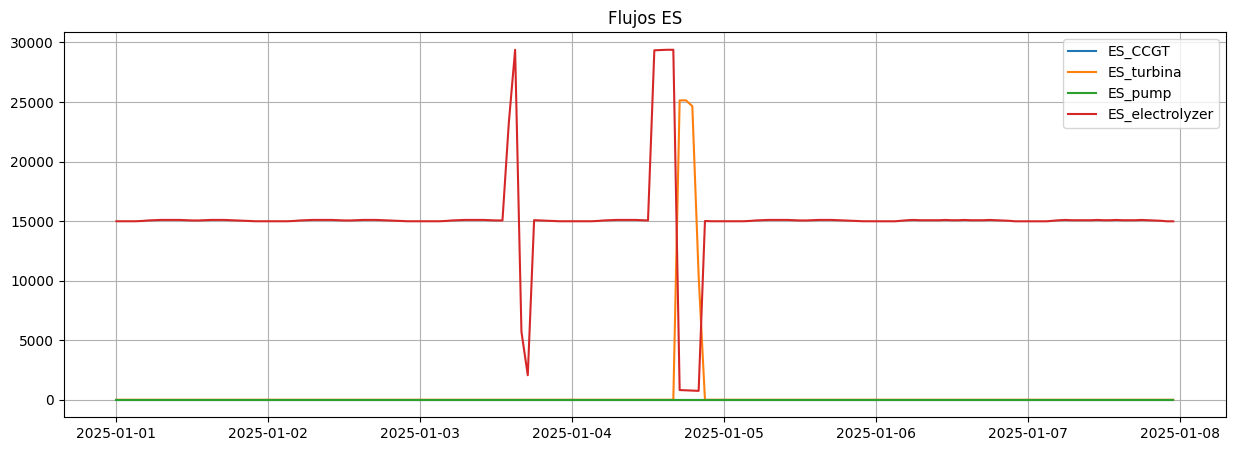

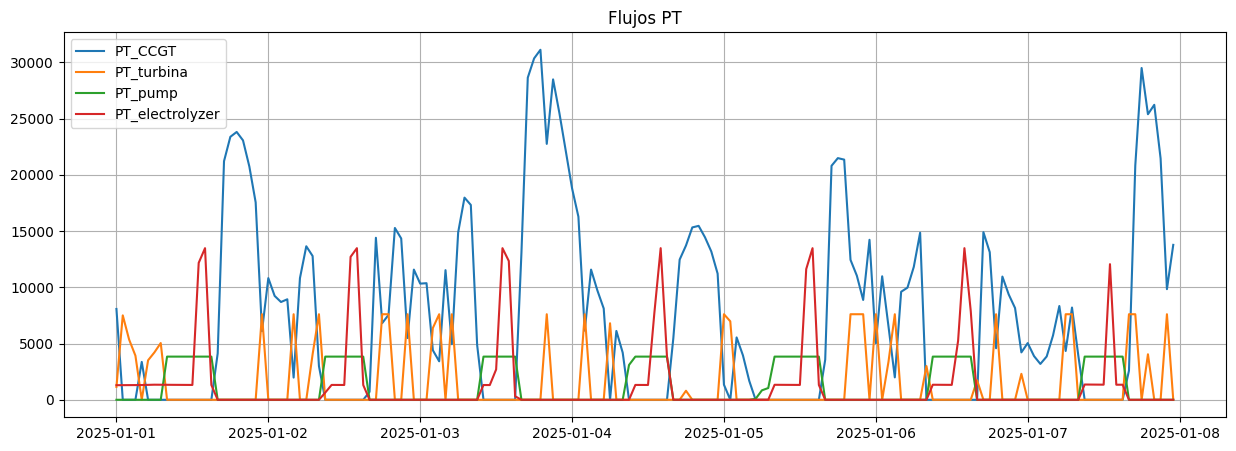

In [87]:
p0 = network.links.dynamic["p0"]

links_ES = [l for l in p0.columns if l.startswith("ES")]
links_PT = [l for l in p0.columns if l.startswith("PT")]

# --- GRAFICO ESPAÑA ---
plt.figure(figsize=(15,5))
for link in links_ES:
    plt.plot(network.snapshots, p0[link], label=link)
plt.title("Flujos ES")
plt.legend()
plt.grid(True)
plt.show()

# --- GRAFICO PORTUGAL ---
plt.figure(figsize=(15,5))
for link in links_PT:
    plt.plot(network.snapshots, p0[link], label=link)
plt.title("Flujos PT")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\3558469089.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\3558469089.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\3558469089.py:9: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



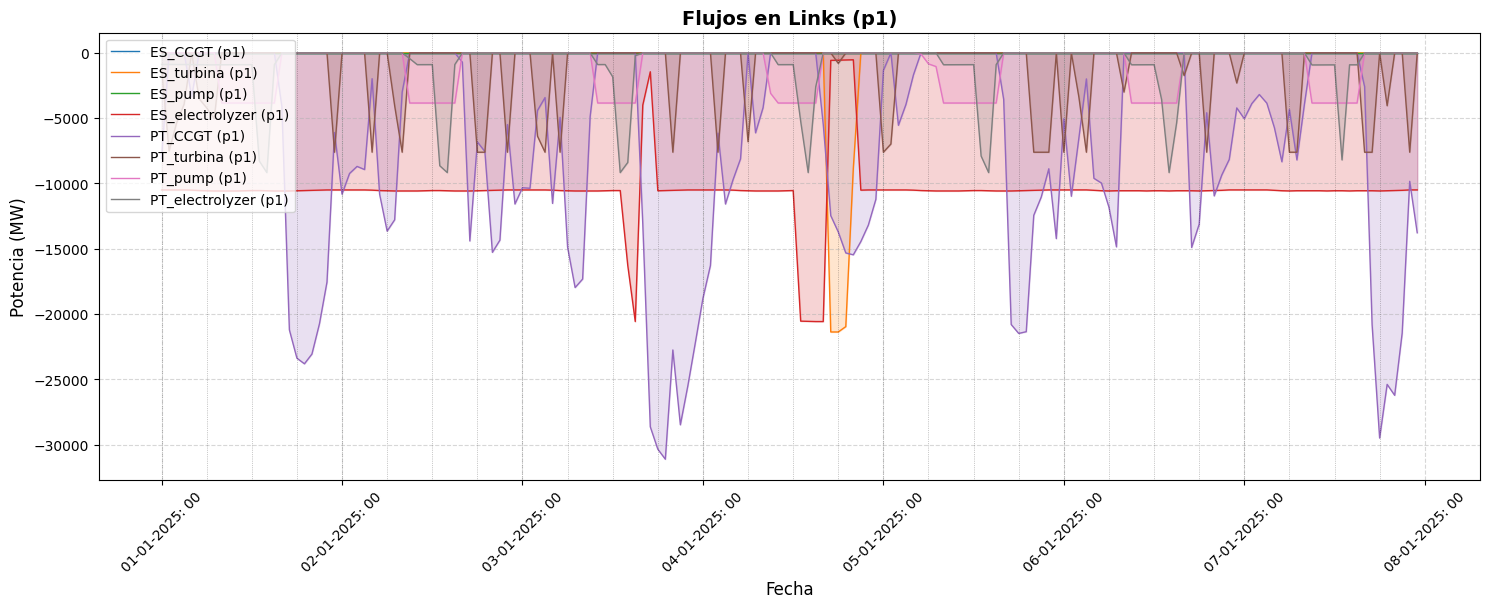

In [88]:

# Asegurar las horas correctas
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H")

plt.figure(figsize=(15, 6))
plt.style.use('default')

# Graficar cada link manualmente (p1)
for link in network.links_t.p1.columns:
    y = network.links_t.p1[link]
    plt.plot(hours, y, label=f"{link} (p1)", linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)

# Personalización
plt.title("Flujos en Links (p1)", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Líneas verticales
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.show()

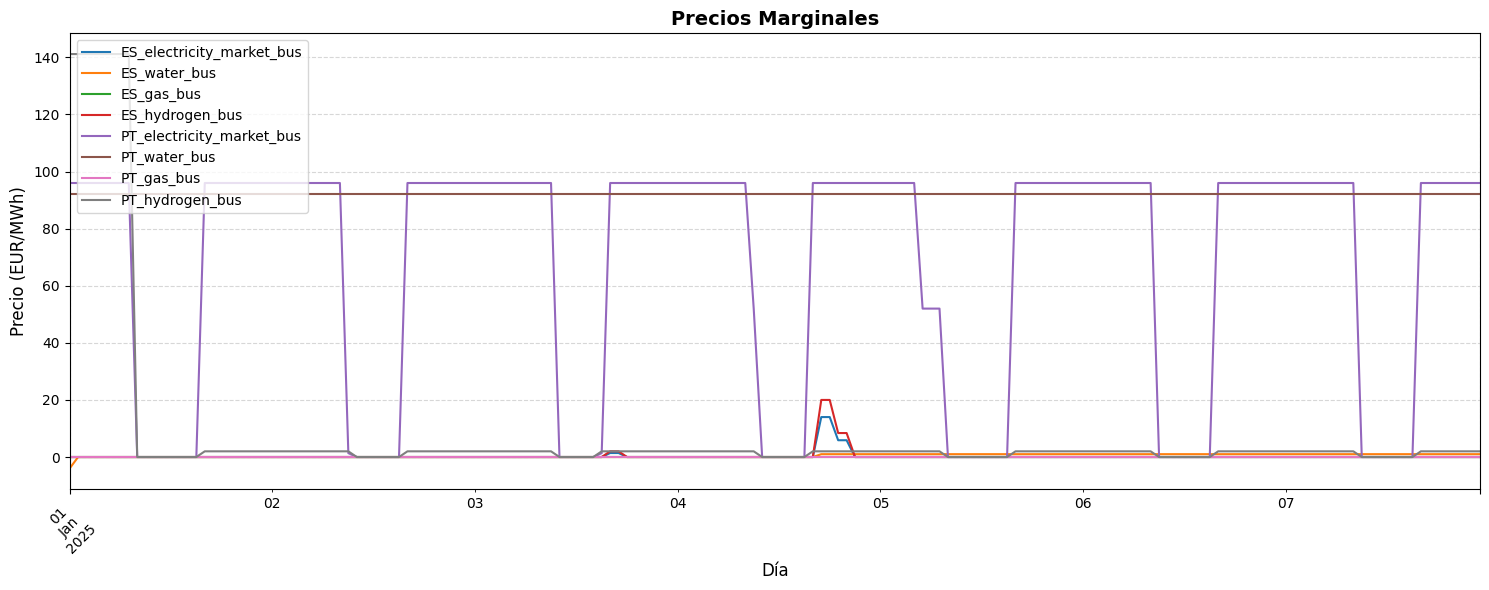

In [89]:
# PRECIOS MARGINALES con API moderna
network.buses.dynamic["marginal_price"].plot(figsize=(15, 6), title="Precios Marginales")

# Personalización
plt.title("Precios Marginales", fontsize=14, fontweight="bold")
plt.xlabel("Día", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\2484443838.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\2484443838.py:26: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\2484443838.py:32: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\2484443838.py:47: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_u

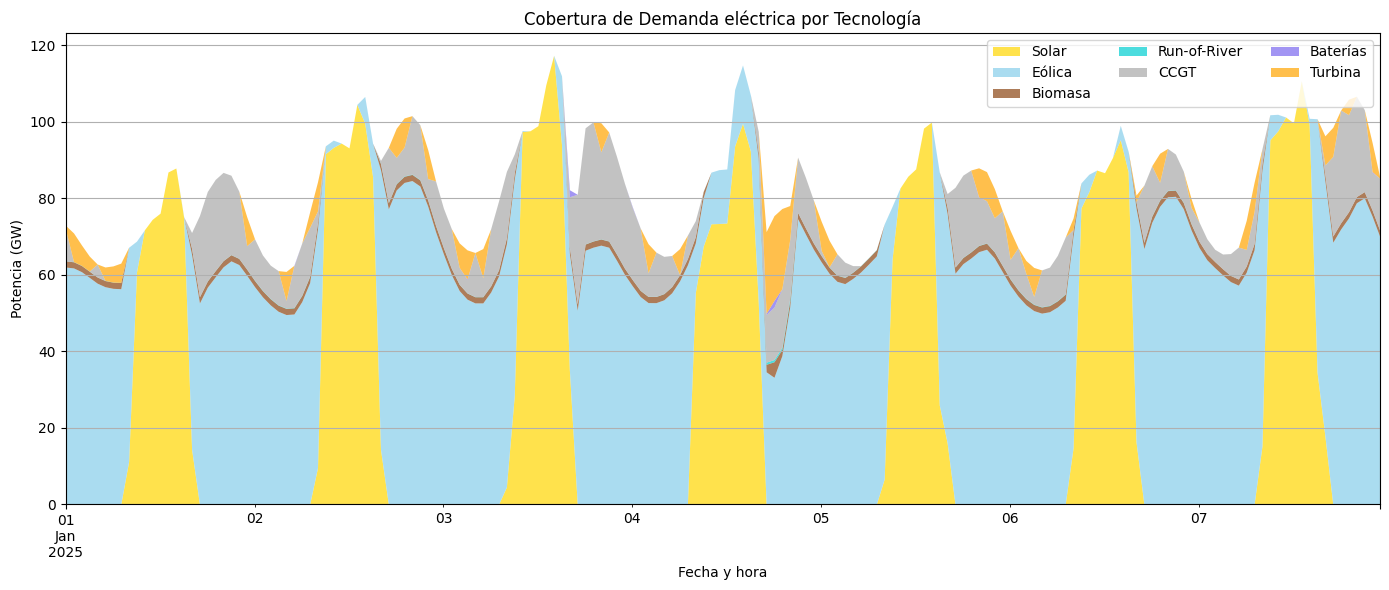

In [90]:
# 1) Índice temporal (snapshots)
times = network.snapshots

# 2) Generación por generador (nuevo API)
gen = network.generators_t.p
gen_car = network.generators.static["carrier"].str.lower()

# 3) Renovables por carrier
renew_carriers = ["solar", "wind", "biomass", "water", "gas"]
renew_series = {
    car: gen.loc[:, gen_car == car].sum(axis=1)
    for car in renew_carriers
}

# ------------------------------
# 4) Links: CCGT, Turbina (nuevo API)
# ------------------------------

# Para ser robusto, filtra por nombre en .links.static
links_car = network.links.static.index.str.lower()

# CCGT
ccgt_name = [n for n in network.links.static.index if "ccgt" in n.lower()]
if len(ccgt_name) == 0:
    print("⚠ No se encontró ningún link con 'CCGT'")
CCGT = -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0)

# Turbina
turb_name = [n for n in network.links.static.index if "turbina" in n.lower()]
if len(turb_name) == 0:
    print("⚠ No se encontró ningún link con 'turbina'")
turb = -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0)

# ------------------------------
# 5) Storage Units (nuevo API)
# ------------------------------

su_names = network.storage_units.static.index.str.lower()

battery_sus = [n for n in network.storage_units.static.index 
               if "electricity_market_battery" in n.lower()]

h2_sus = [n for n in network.storage_units.static.index 
          if "hydrogen_storage" in n.lower()]

# 6) Potencia neta
bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

battery_discharge = bat_net.clip(lower=0)
h2_discharge = h2_net.clip(lower=0)

# ------------------------------
# 7) Construir DataFrame final
# ------------------------------

df_plot = pd.DataFrame({
    "Solar":         renew_series["solar"]     / 1e3,
    "Eólica":        renew_series["wind"]      / 1e3,
    "Biomasa":       renew_series["biomass"]   / 1e3,
    "Run-of-River":  renew_series["water"]     / 1e3,
    "CCGT":          CCGT                      / 1e3,
    "Baterías":      battery_discharge         / 1e3,
    # "H2 Storage":     h2_discharge            / 1e3,
    "Turbina":       turb                      / 1e3,
}, index=times)

# ------------------------------
# 8) Colores
# ------------------------------

colors = {
    "Solar":        "#FFD700",
    "Eólica":       "#87CEEB",
    "Biomasa":      "#8B4513",
    "Run-of-River": "#00CED1",
    "CCGT":         "#A9A9A9",
    "Baterías":     "#7B68EE",
    "Turbina":      "#FFA500",
}

c = [colors[col] for col in df_plot.columns]

# ------------------------------
# 9) Gráfica
# ------------------------------

fig, ax = plt.subplots(figsize=(14, 6))
df_plot.plot(kind="area", ax=ax, color=c, alpha=0.7, linewidth=0)

ax.set_title("Cobertura de Demanda eléctrica por Tecnología")
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Potencia (GW)")
ax.legend(loc="upper right", ncol=3)
ax.grid(True)
plt.tight_layout()
plt.show()

In [91]:
# ----------------------------- DEMANDA NACIONAL -----------------------------
national_demand = network.loads_t.p_set["demand_2040"] / 1e3   # MW → GW

# ----------------------------- STORAGE UNITS --------------------------------
# En nuevo API: la tabla está en .storage_units.static
su_index = network.storage_units.static.index

# Selección robusta por nombre
battery_sus = [n for n in su_index if "battery" in n.lower()]
h2_sus      = [n for n in su_index if "hstor"  in n.lower()]

# ------------------------- CARGA DE BATERÍAS / H2 ---------------------------
# storage_units_t.p > 0  → descarga a la red (oferta)
# storage_units_t.p < 0  → toma energía de la red (carga)

battery_charge = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)               # dejamos solo la carga (valores negativos)
    .sum(axis=1)
    .abs() / 1e3                 # MW → GW
)

h2_charge = (
    network.storage_units_t.p[h2_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs() / 1e3
)

# ------------------------- BOMBEO HIDRÁULICO --------------------------------
# Nuevo API: nombres en network.links.static.index
link_index = network.links.static.index

pumped_links = [l for l in link_index
                if "pump" in l.lower() or "bombeo" in l.lower()]

pumping_demand = (
    network.links_t.p0[pumped_links]     # p0 positivo = consumo eléctrico
    .clip(lower=0)
    .sum(axis=1) / 1e3                   # MW → GW
)

# --------------------------- ELECTROLIZADORES --------------------------------
electrolyzer_links = [l for l in link_index if "electrolyzer" in l.lower()]

electrolyzer_demand = (
    network.links_t.p0[electrolyzer_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
)

# Si quieres descontar la carga de H₂ (opcional)
electrolyzer_demand_final = electrolyzer_demand - h2_charge

# --------------------------- GRÁFICA STACKPLOT -------------------------------
plt.figure(figsize=(14, 6))

plt.stackplot(
    national_demand.index,
    national_demand,
    battery_charge,
    h2_charge,
    pumping_demand,
    electrolyzer_demand_final,
    labels=[
        "Demanda",
        "Carga Baterías",
        "Carga H₂",
        "Bombeo Hidráulico",
        "Electrólisis",
    ],
    colors=[
        "#FFD700",  # Demanda
        "#9370DB",  # Carga Baterías
        "#32CD32",  # Carga H2
        "#00CED1",  # Bombeo
        "#FFA500",  # Electrólisis
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))

plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_30628\2471432107.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.



KeyError: 'demand_2040'

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_12268\3094367298.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_12268\3094367298.py:11: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



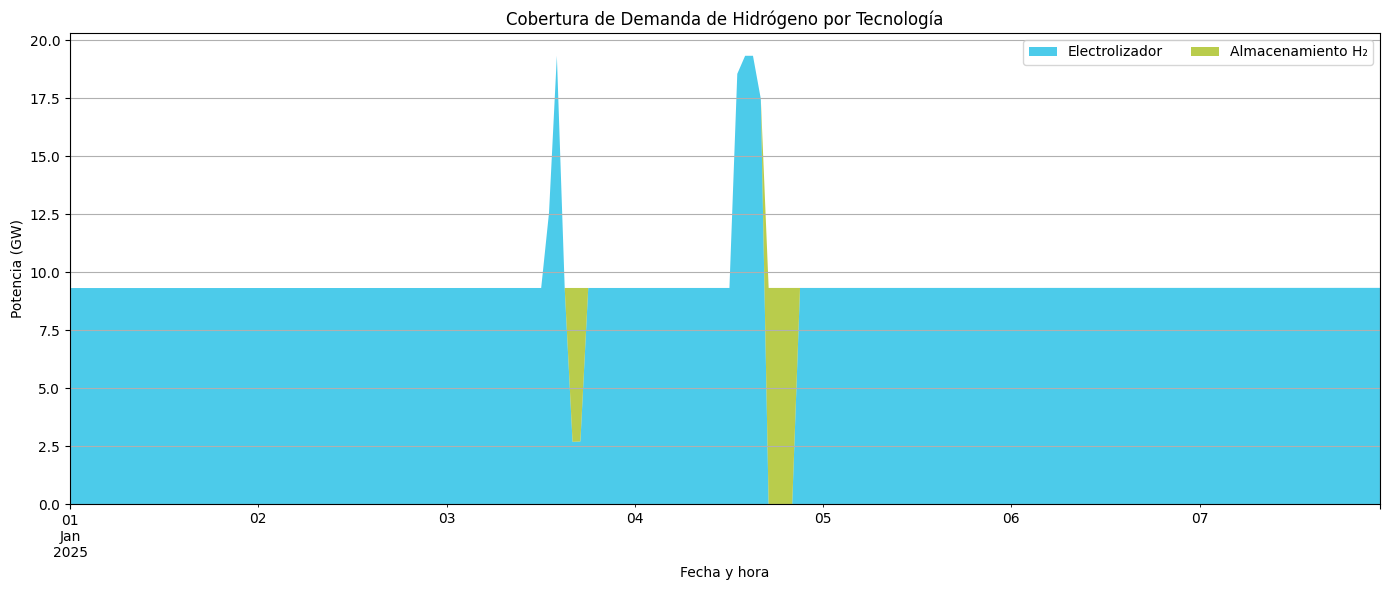

In [ ]:
# ------------------ Índice temporal ---------------------------------------------------------
times = network.snapshots
# ------------------ Electrolizador ----------------------------------------------------------
# Potencia eléctrica consumida para producir H₂ (en MW)
electrolyzer = -network.links_t.p1[["electrolyzer"]].clip(upper=0) 
electrolyzer = electrolyzer.iloc[:, 0]  
# ------------------ Almacenamiento H₂ -------------------------------------------------------
# Identifica unidades de almacenamiento de H₂
h2_sus = [n for n in network.storage_units.static.index if "hydrogen_storage" in n.lower()]
# Potencia neta (descarga positiva) ----------------------------------------------------------
h2_net = network.storage_units_t.p[h2_sus].sum(axis=1)
h2_discharge = h2_net.clip(lower=0)
# ------------------ DataFrame para la gráfica -----------------------------------------------
df_plot = pd.DataFrame({
    "Electrolizador": electrolyzer / 1e3,        # GW
    "Almacenamiento H₂": h2_discharge / 1e3,     # GW
}, index=times)
# ------------------ Colores -----------------------------------------------------------------
colors = {
    "Electrolizador": "#00B5E2",
    "Almacenamiento H₂": "#9CB700",
}
c = [colors[col] for col in df_plot.columns]
# ------------------ Gráfica -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
df_plot.plot(kind="area", ax=ax, color=c, alpha=0.7, linewidth=0)
ax.set_title("Cobertura de Demanda de Hidrógeno por Tecnología")
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Potencia (GW)")
ax.legend(loc="upper right", ncol=2)
ax.grid(True)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_12268\3286270969.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_12268\3286270969.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



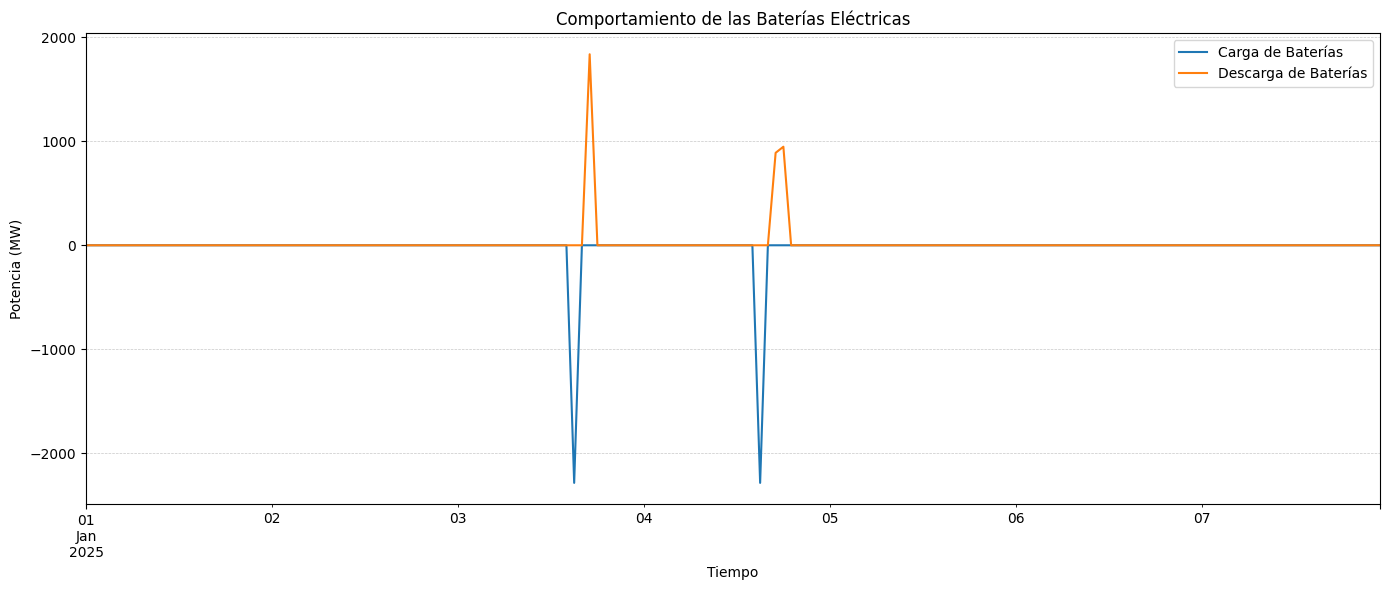

In [ ]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(14, 6))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# OJO

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_12268\2294808147.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



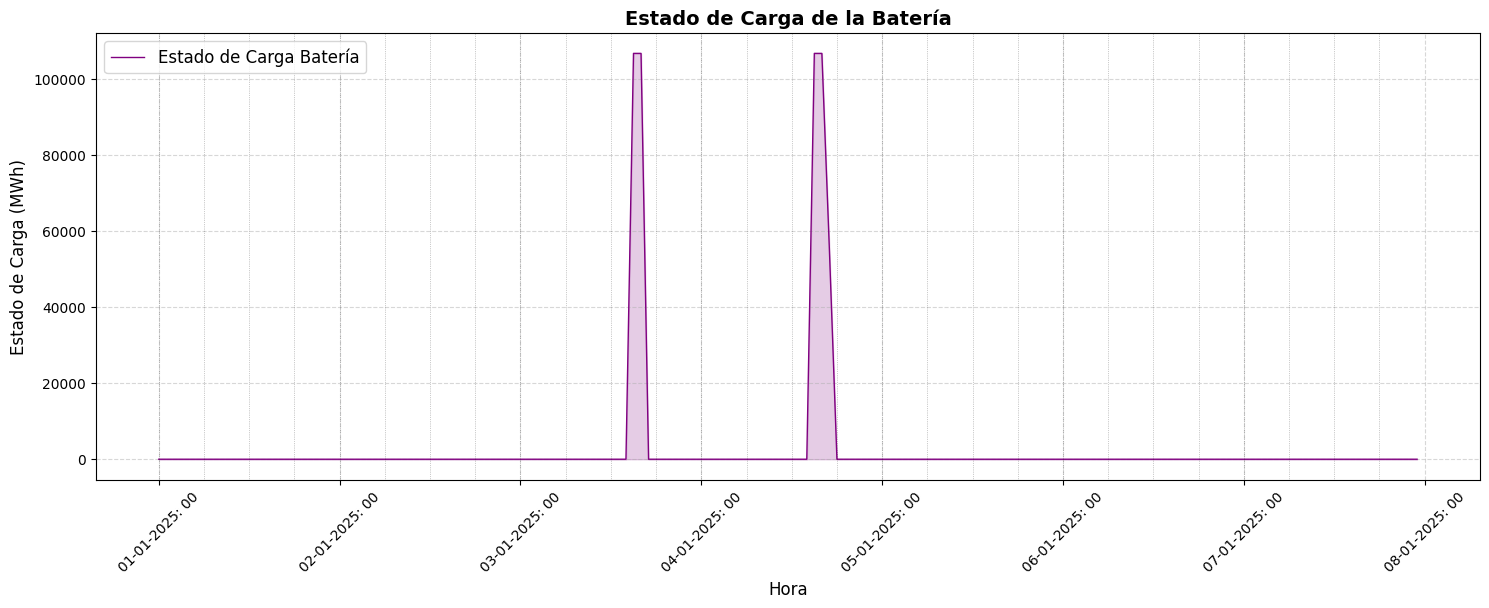

In [ ]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["electricity_market_battery"]
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_12268\3799533437.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



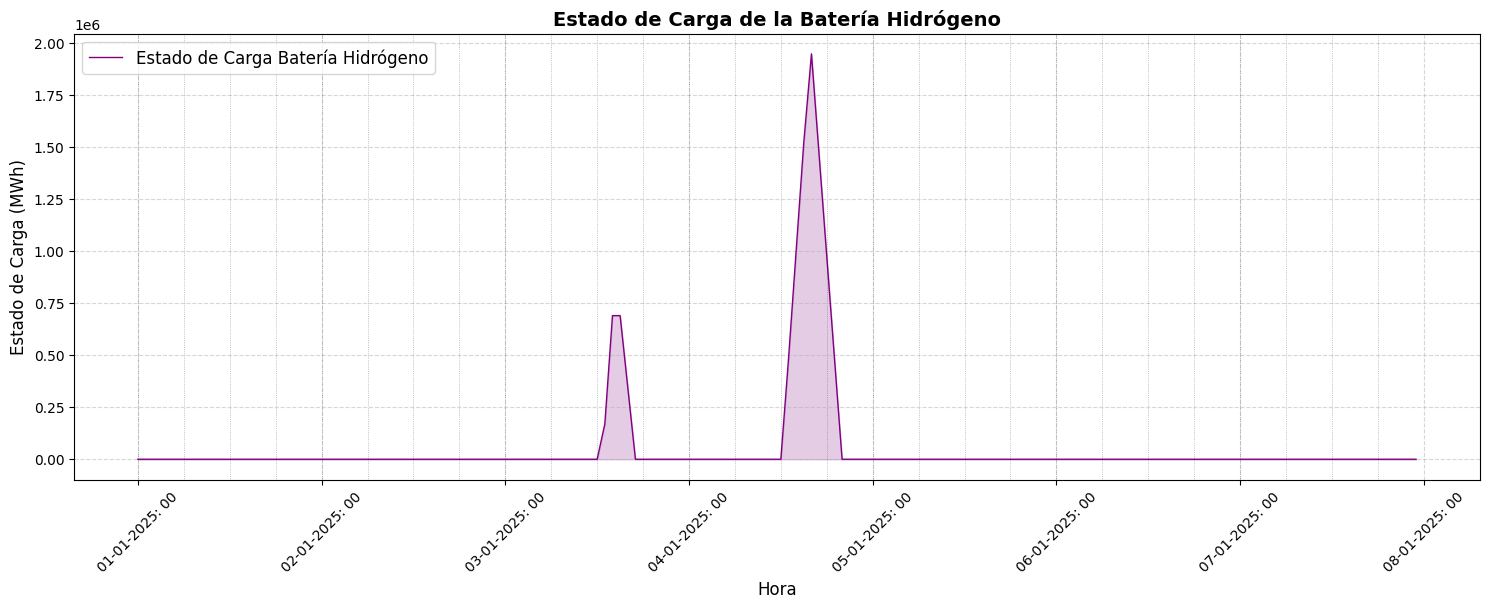

In [ ]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["hydrogen_storage"]
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería Hidrógeno", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Hidrógeno", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()